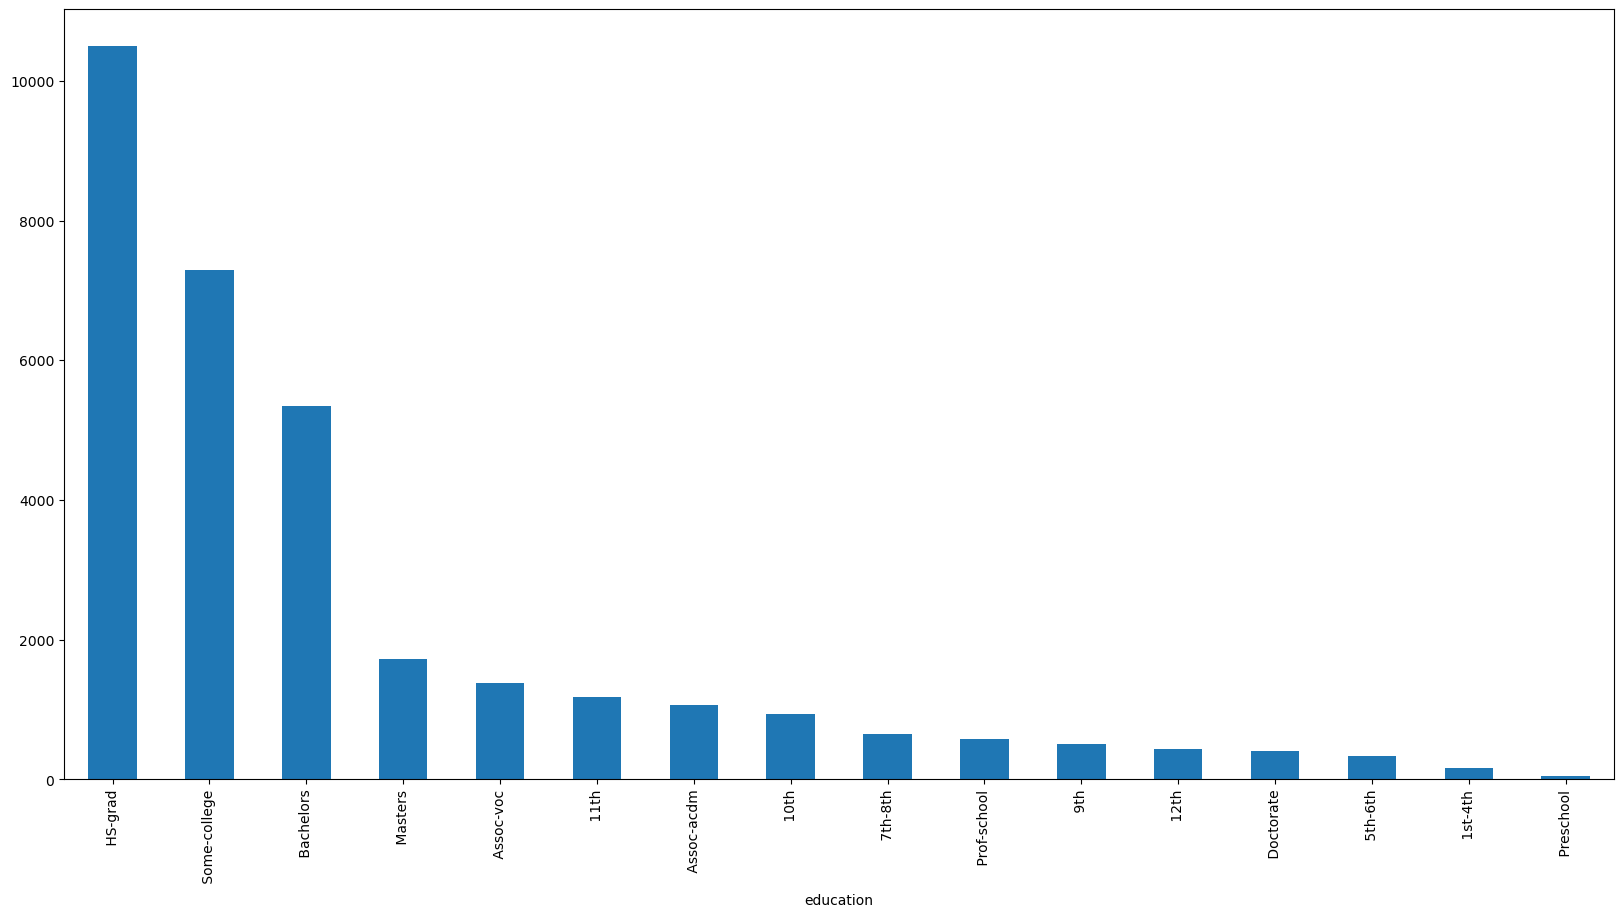

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
headers=['age','workclass','fnlwgt','education','eduNum','ms','occupation','religion','race','sex','cg','cl','hpw','nc','class']
df=pd.read_csv('C:\\Users\\Elayaraja\\Downloads\\adult\\adult.data',delimiter=',')
data=df.to_csv('adult.data', header=headers,index=False)
data2=pd.read_csv('adult.data')
df1=pd.DataFrame(data2)
plt.figure(figsize=(20,10))
df1['education'].value_counts().plot(kind='bar')
plt.show()
#data.head(5)

In [18]:
df1['class'] = df1['class'].str.strip('.').str.strip()
print("Cleaned 'class' column unique values:")
print(df1['class'].unique())

Cleaned 'class' column unique values:
['<=50K' '>50K']


In [19]:
categorical_cols = df1.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('class')

df_encoded = pd.get_dummies(df1, columns=categorical_cols, drop_first=True)

print("Original DataFrame shape:", df1.shape)
print("Encoded DataFrame shape:", df_encoded.shape)
print("First 5 rows of the encoded DataFrame:")
print(df_encoded.head())

Original DataFrame shape: (32560, 15)
Encoded DataFrame shape: (32560, 101)
First 5 rows of the encoded DataFrame:
   age  fnlwgt  eduNum  cg  cl  hpw  class  workclass_ Federal-gov  \
0   50   83311      13   0   0   13  <=50K                   False   
1   38  215646       9   0   0   40  <=50K                   False   
2   53  234721       7   0   0   40  <=50K                   False   
3   28  338409      13   0   0   40  <=50K                   False   
4   37  284582      14   0   0   40  <=50K                   False   

   workclass_ Local-gov  workclass_ Never-worked  ...  nc_ Portugal  \
0                 False                    False  ...         False   
1                 False                    False  ...         False   
2                 False                    False  ...         False   
3                 False                    False  ...         False   
4                 False                    False  ...         False   

   nc_ Puerto-Rico  nc_ Scotland  nc_

In [20]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (26048, 100)
Shape of X_test: (6512, 100)
Shape of y_train: (26048,)
Shape of y_test: (6512,)


In [21]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


In [22]:
y_pred = model.predict(X_test)
print("Predictions made on the test set.")

Predictions made on the test set.


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='>50K')
recall = recall_score(y_test, y_pred, pos_label='>50K')
f1 = f1_score(y_test, y_pred, pos_label='>50K')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.8506
Precision: 0.7283
Recall: 0.6250
F1-Score: 0.6727
